In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

In [3]:
path = '/content/drive/MyDrive/dataset_dl_lab/REI_dataset'

In [4]:
room_types = []

for item in os.listdir(path):

    item_path = os.path.join(path, item)

    # Ignore README.docx or other files
    if os.path.isdir(item_path):

        room_types.append(item)

print(room_types)

print("Total Categories:", len(room_types))

['livingRoom', 'kitchen', 'bathroom', 'backyard', 'frontyard', 'bedroom']
Total Categories: 6


In [5]:
rooms = []

for category in room_types:

    category_path = os.path.join(path, category)

    for file in os.listdir(category_path):

        image_path = os.path.join(category_path, file)

        rooms.append([category, image_path])

rooms_df = pd.DataFrame(
    rooms,
    columns=['room_type', 'image']
)

rooms_df.head()

,room_type,image
0,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
1,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
2,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
3,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
4,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...


In [6]:
print("Total Images:", len(rooms_df))

print("\nImages Per Category:\n")

print(rooms_df['room_type'].value_counts())

Total Images: 5859

Images Per Category:

room_type
bedroom       1593
kitchen        992
frontyard      884
livingRoom     852
bathroom       793
backyard       745
Name: count, dtype: int64


In [21]:
im_size = 64

images = []
labels = []

for category in room_types:

    category_path = os.path.join(path, category)

    for file in os.listdir(category_path):

        img_path = os.path.join(category_path, file)

        img = cv2.imread(img_path)

        # Ignore corrupted images
        if img is not None:

            img = cv2.resize(
                img,
                (im_size, im_size)
            )

            images.append(img)

            labels.append(category)

In [22]:
images = np.array(images, dtype='float32')

labels = np.array(labels)

print(images.shape)

print(labels.shape)

(5859, 64, 64, 3)
(5859,)


In [23]:
images = images / 255.0

In [24]:
encoder = LabelEncoder()
y = encoder.fit_transform(labels)
print(y[:10])

[5 5 5 5 5 5 5 5 5 5]


In [25]:
y = keras.utils.to_categorical(y)
print(y.shape)

(5859, 6)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)

(4687, 12288)


In [28]:
model = keras.Sequential([

    keras.layers.Dense(
        256,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    keras.layers.BatchNormalization(),

    keras.layers.Dropout(0.4),


    keras.layers.Dense(
        128,
        activation='relu'
    ),

    keras.layers.BatchNormalization(),

    keras.layers.Dropout(0.4),


    keras.layers.Dense(
        64,
        activation='relu'
    ),

    keras.layers.BatchNormalization(),

    keras.layers.Dropout(0.3),


    keras.layers.Dense(
        y.shape[1],
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,189,318 (12.17 MB)

 Trainable params: 3,188,422 (12.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.3326 - loss: 1.8036 - val_accuracy: 0.4676 - val_loss: 1.3957
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4227 - loss: 1.4286 - val_accuracy: 0.4881 - val_loss: 1.1562
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4630 - loss: 1.2926 - val_accuracy: 0.5060 - val_loss: 1.1359
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4988 - loss: 1.2274 - val_accuracy: 0.5265 - val_loss: 1.1644
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5080 - loss: 1.1796 - val_accuracy: 0.5444 - val_loss: 1.1132
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5204 - loss: 1.1540 - val_accuracy: 0.5273 - val_loss: 1.1541
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5374 - loss: 1.1184 - val_accuracy: 0.5171 - val_loss: 1.2035
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5419 - loss: 1.1059 - val_accuracy: 

In [32]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5589 - loss: 1.1131
Test Accuracy: 0.55887371301651


In [33]:
predictions = model.predict(X_test)

predicted_class = np.argmax(
    predictions,
    axis=1
)

actual_class = np.argmax(
    y_test,
    axis=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


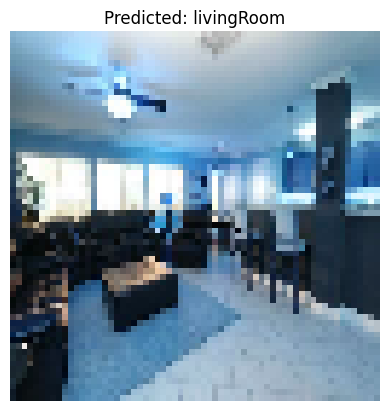

In [35]:
plt.imshow(
    X_test[0].reshape(64,64,3)
)

plt.title(

    "Predicted: " +

    encoder.inverse_transform(
        [predicted_class[0]]
    )[0]
)

plt.axis('off')

plt.show()